# Import

In [2]:
import numpy as np
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import learning_curve
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    precision_recall_curve, recall_score
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import make_pipeline

import lightgbm as lgb


/Users/adrien/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = kagglehub.load_dataset(
KaggleDatasetAdapter.PANDAS,
"mkechinov/ecommerce-behavior-data-from-multi-category-store",
"2019-Oct.csv",
pandas_kwargs={
"nrows": 5_000_000,
"dtype": {
'event_type': 'category',
'product_id': 'int32',
'category_code': 'category',
'brand': 'category',
'price': 'float32',
'user_id': 'int32',
}
}
)

/var/folders/z0/wpl2lwrs3rx3w51w3jxdmvfc0000gp/T/ipykernel_35659/827037083.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


# EDA/Cleaning

In [4]:
# Verify temporal range
print(df['event_time'].min(), df['event_time'].max())

2019-10-01 00:00:00 UTC 2019-10-05 01:32:45 UTC


In [5]:
df['event_type'].value_counts(normalize=True)

event_type
view        0.963445
cart        0.019490
purchase    0.017064
Name: proportion, dtype: float64

This specific retailer doesn't use remove_from_cart event. They are using override cart mechanics in API. So you can figured out removed from cart products as difference between purchase and cart events.

In [6]:
df['category_id'].nunique()

557

In [7]:
df['product_id'].nunique()

104341

In [8]:
df['category_code'].nunique()

123

In [9]:
#Clean the event time, remove UTC

df["event_time"] = pd.to_datetime(
    df["event_time"].str.replace(" UTC", "", regex=False),
    format="%Y-%m-%d %H:%M:%S",
)

In [10]:
# Stats descriptives (colonnes numériques)
df.describe()

,event_time,product_id,category_id,price,user_id
count,5000000,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06
mean,2019-10-03 01:03:22.693881344,9.952775e+06,2.056480e+18,2.993087e+02,5.313978e+08
min,2019-10-01 00:00:00,1.001588e+06,2.053014e+18,0.000000e+00,1.835035e+08
25%,2019-10-02 00:38:20.750000128,1.005115e+06,2.053014e+18,6.595000e+01,5.155534e+08
50%,2019-10-03 03:22:41,4.804056e+06,2.053014e+18,1.660300e+02,5.270384e+08
75%,2019-10-04 05:07:00,1.560002e+07,2.053014e+18,3.704100e+02,5.482997e+08
max,2019-10-05 01:32:45,5.490001e+07,2.175420e+18,2.574070e+03,5.568893e+08
std,NaN,1.115953e+07,1.626111e+16,3.677196e+02,1.694442e+07


In [11]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'missing': missing, '%': missing_pct}).query('missing > 0').sort_values('%', ascending=False)

,missing,%
category_code,1551052,31.0
brand,695695,13.9


In [12]:
df['user_id'].nunique()

611800

In [13]:
df_purchase = df.groupby('category_code')['event_type'].apply(lambda x: (x == 'purchase').sum())

/var/folders/z0/wpl2lwrs3rx3w51w3jxdmvfc0000gp/T/ipykernel_35659/985662042.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_purchase = df.groupby('category_code')['event_type'].apply(lambda x: (x == 'purchase').sum())


In [14]:
df_purchase.sort_values(ascending=False)

category_code
electronics.smartphone         40063
electronics.audio.headphone     3895
electronics.video.tv            2465
electronics.clocks              2253
computers.notebook              2029
                               ...  
apparel.shorts                     0
apparel.dress                      0
sport.tennis                       0
apparel.skirt                      0
apparel.jacket                     0
Name: event_type, Length: 123, dtype: int64

In [15]:
(df_purchase / df_purchase.sum() * 100).sort_values(ascending=False)

category_code
electronics.smartphone         59.771435
electronics.audio.headphone     5.811091
electronics.video.tv            3.677622
electronics.clocks              3.361332
computers.notebook              3.027138
                                 ...    
apparel.shorts                  0.000000
apparel.dress                   0.000000
sport.tennis                    0.000000
apparel.skirt                   0.000000
apparel.jacket                  0.000000
Name: event_type, Length: 123, dtype: float64

In [16]:
# Lister les catégories à 0 achats
df_purchase[df_purchase == 0].index.tolist()
# Combien il y en a
(df_purchase == 0).sum()

np.int64(11)

In [17]:
# Catégories avec au moins 1 achat
df_purchase_clean = df_purchase[df_purchase > 0].sort_values(ascending=False)
df_purchase_clean

category_code
electronics.smartphone         40063
electronics.audio.headphone     3895
electronics.video.tv            2465
electronics.clocks              2253
computers.notebook              2029
                               ...  
apparel.sock                       1
apparel.scarf                      1
auto.accessories.winch             1
sport.snowboard                    1
apparel.belt                       1
Name: event_type, Length: 112, dtype: int64

In [18]:
df["brand"] = df["brand"].astype(str).replace("nan", "unknown").astype("category")
df["has_brand"] = (df["brand"] != "unknown").astype("int8")

In [19]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'missing': missing, '%': missing_pct}).query('missing > 0').sort_values('%', ascending=False)

,missing,%
category_code,1551052,31.0


In [20]:
df = df.drop_duplicates()

In [21]:
n_bad_price = (df["price"] <= 0).sum()

In [22]:
n_bad_price

np.int64(6855)

In [23]:
df["has_valid_price"] = (df["price"] > 0).astype("int8")

In [104]:
df

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,has_brand,has_valid_price
0,2019-10-01 00:00:00,view,44600062,2103807459595387724,NaN,shiseido,35.790001,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c,1,1
1,2019-10-01 00:00:00,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.200001,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc,1,1
2,2019-10-01 00:00:01,view,17200506,2053013559792632471,furniture.living_room.sofa,unknown,543.099976,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8,0,1
3,2019-10-01 00:00:01,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,1,1
4,2019-10-01 00:00:04,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,1,1
...,...,...,...,...,...,...,...,...,...,...,...
4999995,2019-10-05 01:32:44,view,12714113,2053013553559896355,NaN,triangle,41.439999,556596992,030a130a-2246-4838-9a7f-83c10e673158,1,1
4999996,2019-10-05 01:32:45,view,1004249,2053013555631882655,electronics.smartphone,apple,730.260010,546177242,4efcfee7-cdbe-4eb7-be55-06b48de6d383,1,1
4999997,2019-10-05 01:32:45,view,1600587,2053013553056579841,computers.peripherals.printer,epson,205.410004,531386105,7d7d6194-7225-469e-b85f-65c2d62a4390,1,1
4999998,2019-10-05 01:32:45,view,50600022,2134905044833666047,auto.accessories.compressor,unknown,129.750000,548323969,af36902c-4068-4537-8b4d-fdee8c89298b,0,1


# Preprocessing X, y

## Filtering X to keep only top 5 category_code

In [105]:
top5 = ['electronics.smartphone', 'electronics.audio.headphone', 'electronics.video.tv',
        'electronics.clocks', 'computers.notebook']

X = df[df['category_code'].isin(top5)]

In [106]:
X

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,has_brand,has_valid_price
3,2019-10-01 00:00:01,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,1,1
4,2019-10-01 00:00:04,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,1,1
9,2019-10-01 00:00:11,view,1004545,2053013555631882655,electronics.smartphone,huawei,566.010010,537918940,406c46ed-90a4-4787-a43b-59a410c1a5fb,1,1
11,2019-10-01 00:00:11,view,1005011,2053013555631882655,electronics.smartphone,samsung,900.640015,530282093,50a293fb-5940-41b2-baf3-17af0e812101,1,1
16,2019-10-01 00:00:18,view,1801995,2053013554415534427,electronics.video.tv,haier,193.029999,537192226,e3151795-c355-4efa-acf6-e1fe1bebeee5,1,1
...,...,...,...,...,...,...,...,...,...,...,...
4999975,2019-10-05 01:32:41,view,1005008,2053013555631882655,electronics.smartphone,xiaomi,99.620003,548698620,bb696742-5927-4127-812b-c95b525155c5,1,1
4999977,2019-10-05 01:32:42,view,1003535,2053013555631882655,electronics.smartphone,samsung,460.500000,535447804,b2e764e9-7a06-4cd1-9485-beb7ff39c201,1,1
4999986,2019-10-05 01:32:43,view,4804295,2053013554658804075,electronics.audio.headphone,xiaomi,22.340000,514708716,5812835f-d2b1-4984-8182-c436088ab653,1,1
4999996,2019-10-05 01:32:45,view,1004249,2053013555631882655,electronics.smartphone,apple,730.260010,546177242,4efcfee7-cdbe-4eb7-be55-06b48de6d383,1,1


In [107]:
X = X.drop_duplicates()
# Il reste 35% des lignes, donc 1/3 des events sont compris sur ces 5 catégories

In [108]:
missing = X.isnull().sum()
missing_pct = (missing / len(X) * 100).round(1)
pd.DataFrame({'missing': missing, '%': missing_pct}).query('missing > 0').sort_values('%', ascending=False)

,missing,%


In [109]:
X = X.sort_values("event_time").reset_index(drop=True)

In [111]:
X

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,has_brand,has_valid_price
0,2019-10-01 00:00:01,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,1,1
1,2019-10-01 00:00:04,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,1,1
2,2019-10-01 00:00:11,view,1004545,2053013555631882655,electronics.smartphone,huawei,566.010010,537918940,406c46ed-90a4-4787-a43b-59a410c1a5fb,1,1
3,2019-10-01 00:00:11,view,1005011,2053013555631882655,electronics.smartphone,samsung,900.640015,530282093,50a293fb-5940-41b2-baf3-17af0e812101,1,1
4,2019-10-01 00:00:18,view,1801995,2053013554415534427,electronics.video.tv,haier,193.029999,537192226,e3151795-c355-4efa-acf6-e1fe1bebeee5,1,1
...,...,...,...,...,...,...,...,...,...,...,...
1990859,2019-10-05 01:32:41,view,1005008,2053013555631882655,electronics.smartphone,xiaomi,99.620003,548698620,bb696742-5927-4127-812b-c95b525155c5,1,1
1990860,2019-10-05 01:32:42,view,1003535,2053013555631882655,electronics.smartphone,samsung,460.500000,535447804,b2e764e9-7a06-4cd1-9485-beb7ff39c201,1,1
1990861,2019-10-05 01:32:43,view,4804295,2053013554658804075,electronics.audio.headphone,xiaomi,22.340000,514708716,5812835f-d2b1-4984-8182-c436088ab653,1,1
1990862,2019-10-05 01:32:45,view,1004249,2053013555631882655,electronics.smartphone,apple,730.260010,546177242,4efcfee7-cdbe-4eb7-be55-06b48de6d383,1,1


## Set Observation and prediction period for X

In [112]:

observation_end = pd.Timestamp("2019-10-03")
prediction_end  = pd.Timestamp("2019-10-05")

In [113]:
X_obs = X[X["event_time"] < observation_end].copy()
X_pred = X[X["event_time"] >= observation_end].copy()

In [114]:
X_obs

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,has_brand,has_valid_price
0,2019-10-01 00:00:01,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,1,1
1,2019-10-01 00:00:04,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,1,1
2,2019-10-01 00:00:11,view,1004545,2053013555631882655,electronics.smartphone,huawei,566.010010,537918940,406c46ed-90a4-4787-a43b-59a410c1a5fb,1,1
3,2019-10-01 00:00:11,view,1005011,2053013555631882655,electronics.smartphone,samsung,900.640015,530282093,50a293fb-5940-41b2-baf3-17af0e812101,1,1
4,2019-10-01 00:00:18,view,1801995,2053013554415534427,electronics.video.tv,haier,193.029999,537192226,e3151795-c355-4efa-acf6-e1fe1bebeee5,1,1
...,...,...,...,...,...,...,...,...,...,...,...
950166,2019-10-02 23:59:48,view,1004461,2053013555631882655,electronics.smartphone,xiaomi,252.229996,516224809,b53bbe3b-158e-4378-911a-f1ef5875fe64,1,1
950167,2019-10-02 23:59:50,view,21409758,2053013561579406073,electronics.clocks,unknown,248.910004,516230621,f61fec44-d3e8-48ca-8e0f-492e4e9a2dbe,0,1
950168,2019-10-02 23:59:55,view,1005129,2053013555631882655,electronics.smartphone,apple,1413.160034,514026027,42f11e1b-bbc0-439a-bb93-9a7916f528b8,1,1
950169,2019-10-02 23:59:56,view,1004209,2053013555631882655,electronics.smartphone,samsung,89.839996,515648103,8aeae59c-8d2a-4f51-a0a6-95905436393c,1,1


In [32]:
X_pred

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,has_brand,has_valid_price
950171,2019-10-03 00:00:01,view,1003983,2053013555631882655,electronics.smartphone,huawei,89.809998,518384607,05499939-a33d-42bd-a8b5-e75757420f17,1,1
950172,2019-10-03 00:00:03,view,1003230,2053013555631882655,electronics.smartphone,nokia,115.580002,556174549,af105d2c-537c-449e-98b1-e5fefb939b2a,1,1
950173,2019-10-03 00:00:04,view,1004838,2053013555631882655,electronics.smartphone,oppo,179.139999,538384600,fd72bb38-95e6-4880-888a-445022350990,1,1
950174,2019-10-03 00:00:13,view,21403947,2053013561579406073,electronics.clocks,casio,27.030001,552469659,7c257a4e-57b3-41a0-96c9-1b2539d5b72e,1,1
950175,2019-10-03 00:00:14,view,1004750,2053013555631882655,electronics.smartphone,samsung,197.429993,523349926,3fbc1916-f61a-4de8-82e8-1a57813fcb8e,1,1
...,...,...,...,...,...,...,...,...,...,...,...
1990859,2019-10-05 01:32:41,view,1005008,2053013555631882655,electronics.smartphone,xiaomi,99.620003,548698620,bb696742-5927-4127-812b-c95b525155c5,1,1
1990860,2019-10-05 01:32:42,view,1003535,2053013555631882655,electronics.smartphone,samsung,460.500000,535447804,b2e764e9-7a06-4cd1-9485-beb7ff39c201,1,1
1990861,2019-10-05 01:32:43,view,4804295,2053013554658804075,electronics.audio.headphone,xiaomi,22.340000,514708716,5812835f-d2b1-4984-8182-c436088ab653,1,1
1990862,2019-10-05 01:32:45,view,1004249,2053013555631882655,electronics.smartphone,apple,730.260010,546177242,4efcfee7-cdbe-4eb7-be55-06b48de6d383,1,1


## Create y with purchasers from prediction period

In [141]:
purchasers = set(X_pred.loc[X_pred["event_type"] == "purchase", "user_id"])


In [125]:
len(purchasers)

18372

In [120]:
y_purchasers = pd.DataFrame({"user_id": X_obs["user_id"].unique()})
y_purchasers["label"] = y_purchasers["user_id"].isin(purchasers).astype(int)

In [121]:
y_purchasers["label"].value_counts()
# Sur X_obs, env. 2 500 000 events sont enregistrés pour 375 000 utilisateurs unique, avec 9300 qui achèteront sur l'intervalle d'observation

label
0    163906
1      5175
Name: count, dtype: int64

In [37]:
y_purchasers

,user_id,label
0,550050854,0
1,535871217,0
2,537918940,0
3,530282093,0
4,537192226,0
...,...,...
169076,546948553,0
169077,515429044,0
169078,543640816,0
169079,516465461,0


# Feature engineering X_obs

## Global Features creation per user, for the observation period

In [38]:
X_obs["hour"] = X_obs["event_time"].dt.hour
X_obs["dayofweek"] = X_obs["event_time"].dt.dayofweek  # 0=Lundi
X_obs["is_weekend"] = (X_obs["dayofweek"] >= 5).astype("int8")


In [39]:
X_obs

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,has_brand,has_valid_price,hour,dayofweek,is_weekend
0,2019-10-01 00:00:01,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,1,1,0,1,0
1,2019-10-01 00:00:04,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,1,1,0,1,0
2,2019-10-01 00:00:11,view,1004545,2053013555631882655,electronics.smartphone,huawei,566.010010,537918940,406c46ed-90a4-4787-a43b-59a410c1a5fb,1,1,0,1,0
3,2019-10-01 00:00:11,view,1005011,2053013555631882655,electronics.smartphone,samsung,900.640015,530282093,50a293fb-5940-41b2-baf3-17af0e812101,1,1,0,1,0
4,2019-10-01 00:00:18,view,1801995,2053013554415534427,electronics.video.tv,haier,193.029999,537192226,e3151795-c355-4efa-acf6-e1fe1bebeee5,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
950166,2019-10-02 23:59:48,view,1004461,2053013555631882655,electronics.smartphone,xiaomi,252.229996,516224809,b53bbe3b-158e-4378-911a-f1ef5875fe64,1,1,23,2,0
950167,2019-10-02 23:59:50,view,21409758,2053013561579406073,electronics.clocks,unknown,248.910004,516230621,f61fec44-d3e8-48ca-8e0f-492e4e9a2dbe,0,1,23,2,0
950168,2019-10-02 23:59:55,view,1005129,2053013555631882655,electronics.smartphone,apple,1413.160034,514026027,42f11e1b-bbc0-439a-bb93-9a7916f528b8,1,1,23,2,0
950169,2019-10-02 23:59:56,view,1004209,2053013555631882655,electronics.smartphone,samsung,89.839996,515648103,8aeae59c-8d2a-4f51-a0a6-95905436393c,1,1,23,2,0


In [40]:
behavior = X_obs.groupby("user_id").agg(
    total_events   = ("event_type", "count"),
    total_views    = ("event_type", lambda x: (x == "view").sum()),
    total_carts    = ("event_type", lambda x: (x == "cart").sum()),
    total_purchases= ("event_type", lambda x: (x == "purchase").sum()),
    n_sessions     = ("user_session", "nunique"),
    n_days_active  = ("event_time", lambda x: x.dt.date.nunique()),
)

# Features de comportement dans l'intervalle d'observation choisi
# Prend beaucoup de temps les fonctions lambda, optimisable?

In [41]:
behavior

,total_events,total_views,total_carts,total_purchases,n_sessions,n_days_active
user_id,,,,,,
241587569,1,1,0,0,1,1
244951053,2,2,0,0,1,1
293335683,12,12,0,0,3,1
293957954,4,4,0,0,1,1
304497722,1,1,0,0,1,1
...,...,...,...,...,...,...
556194942,1,1,0,0,1,1
556194974,3,3,0,0,2,1
556194976,2,2,0,0,1,1


In [42]:
behavior["has_ever_carted"] = (behavior["total_carts"] > 0).astype("int8")
behavior["has_ever_purchased"] = (behavior["total_purchases"] > 0).astype("int8")


In [43]:
behavior["has_ever_carted"].value_counts(normalize=True)

has_ever_carted
0    0.918093
1    0.081907
Name: proportion, dtype: float64

In [44]:
behavior["has_ever_purchased"].value_counts(normalize=True)

has_ever_purchased
0    0.906944
1    0.093056
Name: proportion, dtype: float64

In [45]:
behavior["view_to_cart_ratio"] = (
    behavior["total_carts"] / behavior["total_views"].replace(0, 1)
)
behavior["cart_to_purchase_ratio"] = (
    behavior["total_purchases"] / behavior["total_carts"].replace(0, 1)
)

#Est-ce que c'est des bonnes features? L'info est peut-être déjà présente

In [46]:
behavior

,total_events,total_views,total_carts,total_purchases,n_sessions,n_days_active,has_ever_carted,has_ever_purchased,view_to_cart_ratio,cart_to_purchase_ratio
user_id,,,,,,,,,,
241587569,1,1,0,0,1,1,0,0,0.0,0.0
244951053,2,2,0,0,1,1,0,0,0.0,0.0
293335683,12,12,0,0,3,1,0,0,0.0,0.0
293957954,4,4,0,0,1,1,0,0,0.0,0.0
304497722,1,1,0,0,1,1,0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
556194942,1,1,0,0,1,1,0,0,0.0,0.0
556194974,3,3,0,0,2,1,0,0,0.0,0.0
556194976,2,2,0,0,1,1,0,0,0.0,0.0


In [47]:
behavior["cart_to_purchase_ratio"].value_counts(ascending=False)

cart_to_purchase_ratio
0.000000    153347
1.000000     10412
0.500000      1511
2.000000      1315
0.333333       523
             ...  
1.111111         1
6.250000         1
1.363636         1
0.050000         1
0.045455         1
Name: count, Length: 126, dtype: int64

## Session features creation

In [48]:
session_stats = X_obs.groupby(["user_id", "user_session"], as_index=False).agg(
    session_start = ("event_time", "min"),
    session_end   = ("event_time", "max"),
    session_events = ("event_time", "count"),
)

In [49]:
session_stats

,user_id,user_session,session_start,session_end,session_events
0,241587569,8a09b6c6-07e6-4f80-ae22-a6b400fc7894,2019-10-02 11:28:14,2019-10-02 11:28:14,1
1,244951053,91769fdf-461b-4e43-9c73-88a07481b75c,2019-10-01 08:47:35,2019-10-01 08:48:28,2
2,293335683,181dcd66-f81e-4e95-9621-1fa9e31944c4,2019-10-02 17:55:58,2019-10-02 18:00:33,3
3,293335683,25338e7a-fbc9-4ae1-9f98-6fe15e2b7888,2019-10-02 04:50:01,2019-10-02 04:59:09,6
4,293335683,81f93e4c-488d-4cab-a16c-318976afb40b,2019-10-02 04:26:05,2019-10-02 04:27:35,3
...,...,...,...,...,...
245879,556194974,4dc1879c-b5a4-4c5b-9489-3fd51468786b,2019-10-02 23:56:36,2019-10-02 23:56:36,1
245880,556194974,8ce97597-7625-485e-b7ac-39c8146c6188,2019-10-02 23:55:42,2019-10-02 23:55:44,2
245881,556194976,ea42851d-1fa9-4142-a5e8-4c1a4894be36,2019-10-02 23:56:25,2019-10-02 23:57:35,2
245882,556195165,238b94de-747b-4172-b491-61b01f6d962b,2019-10-02 23:57:44,2019-10-02 23:57:44,1


In [50]:
session_stats["user_id"].nunique()
# Environ 2 sessions par user_id

169081

In [51]:
session_stats["session_duration"] = (
    session_stats["session_end"] - session_stats["session_start"]
)

In [153]:
session_stats

,user_id,user_session,session_start,session_end,session_events,session_duration
0,241587569,8a09b6c6-07e6-4f80-ae22-a6b400fc7894,2019-10-02 11:28:14,2019-10-02 11:28:14,1,0 days 00:00:00
1,244951053,91769fdf-461b-4e43-9c73-88a07481b75c,2019-10-01 08:47:35,2019-10-01 08:48:28,2,0 days 00:00:53
2,293335683,181dcd66-f81e-4e95-9621-1fa9e31944c4,2019-10-02 17:55:58,2019-10-02 18:00:33,3,0 days 00:04:35
3,293335683,25338e7a-fbc9-4ae1-9f98-6fe15e2b7888,2019-10-02 04:50:01,2019-10-02 04:59:09,6,0 days 00:09:08
4,293335683,81f93e4c-488d-4cab-a16c-318976afb40b,2019-10-02 04:26:05,2019-10-02 04:27:35,3,0 days 00:01:30
...,...,...,...,...,...,...
245879,556194974,4dc1879c-b5a4-4c5b-9489-3fd51468786b,2019-10-02 23:56:36,2019-10-02 23:56:36,1,0 days 00:00:00
245880,556194974,8ce97597-7625-485e-b7ac-39c8146c6188,2019-10-02 23:55:42,2019-10-02 23:55:44,2,0 days 00:00:02
245881,556194976,ea42851d-1fa9-4142-a5e8-4c1a4894be36,2019-10-02 23:56:25,2019-10-02 23:57:35,2,0 days 00:01:10
245882,556195165,238b94de-747b-4172-b491-61b01f6d962b,2019-10-02 23:57:44,2019-10-02 23:57:44,1,0 days 00:00:00


## EDA Session leading to purchase

In [150]:
df_purchasers = pd.DataFrame({"user_id": X_pred.loc[X_pred["event_type"] == "purchase", "user_id"]})
# Sort les purchasers de la période prédictive, avec plusieurs achats par user_id
df_purchasers["session_with_purchase"] = X_pred.loc[X_pred["event_type"] == "purchase", "user_session"]

In [151]:
df_purchasers

,user_id,session_with_purchase
950182,530576454,853aa7f0-57df-4957-b20f-b29fad882562
950281,556154991,41f50889-8837-4a04-852d-51bd70617304
950299,556195376,8678659c-56db-41fa-9def-ef663f014e15
950302,556195636,5a961db1-711e-43af-9d6c-f1a4249b5176
950342,556154991,41f50889-8837-4a04-852d-51bd70617304
...,...,...
1990736,526010975,2447a0a9-8d38-41e6-9196-6eb4309172b5
1990745,549871473,8a8f7c0a-532a-4b86-ac13-7f0cc6568556
1990762,555965683,2f1b13d2-641f-48bc-b116-3e69113b0911
1990823,517815964,044fee19-fd67-44f1-84bb-3b2de8b5ed9c


In [157]:
session_stats_full = (
    X.groupby(["user_id", "user_session"], as_index=False)
    .agg(
        session_start=("event_time", "min"),
        session_end=("event_time", "max"),
        session_events=("event_time", "count"),
    )
)

session_stats_full["session_duration"] = (
    session_stats_full["session_end"] -
    session_stats_full["session_start"]
)

df_purchase_sessions = df_purchasers.merge(
    session_stats_full,
    left_on="session_with_purchase",
    right_on="user_session",
    how="left"
)

# Nettoyer
df_purchase_sessions = (
    df_purchase_sessions
    .drop(columns=["user_id_y", "user_session"])
    .rename(columns={"user_id_x": "user_id"})
)

In [158]:
df_purchase_sessions

,user_id,session_with_purchase,session_start,session_end,session_events,session_duration
0,530576454,853aa7f0-57df-4957-b20f-b29fad882562,2019-10-02 23:58:03,2019-10-03 00:00:55,8,0 days 00:02:52
1,556154991,41f50889-8837-4a04-852d-51bd70617304,2019-10-03 00:01:36,2019-10-03 00:05:56,8,0 days 00:04:20
2,556195376,8678659c-56db-41fa-9def-ef663f014e15,2019-10-03 00:00:22,2019-10-03 00:04:08,5,0 days 00:03:46
3,556195636,5a961db1-711e-43af-9d6c-f1a4249b5176,2019-10-03 00:02:53,2019-10-03 00:04:10,2,0 days 00:01:17
4,556154991,41f50889-8837-4a04-852d-51bd70617304,2019-10-03 00:01:36,2019-10-03 00:05:56,8,0 days 00:04:20
...,...,...,...,...,...,...
27549,526010975,2447a0a9-8d38-41e6-9196-6eb4309172b5,2019-10-05 01:14:57,2019-10-05 01:31:47,5,0 days 00:16:50
27550,549871473,8a8f7c0a-532a-4b86-ac13-7f0cc6568556,2019-10-05 01:31:13,2019-10-05 01:31:51,3,0 days 00:00:38
27551,555965683,2f1b13d2-641f-48bc-b116-3e69113b0911,2019-10-05 01:26:05,2019-10-05 01:32:23,6,0 days 00:06:18
27552,517815964,044fee19-fd67-44f1-84bb-3b2de8b5ed9c,2019-10-05 01:29:38,2019-10-05 01:32:45,6,0 days 00:03:07


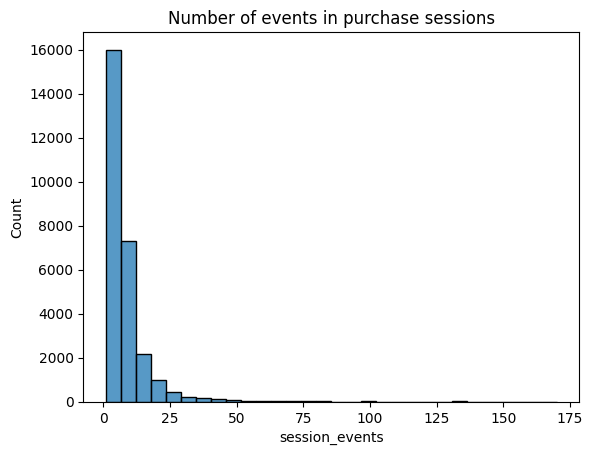

In [163]:
# Distribution des évènements dans la session d'achat

sns.histplot(df_purchase_sessions["session_events"], bins=30)

plt.title("Number of events in purchase sessions")
plt.show()

In [164]:
df_purchase_sessions["session_duration"].describe()

count                        27554
mean     0 days 00:09:41.110437685
std      0 days 01:01:56.780264972
min                0 days 00:00:00
25%                0 days 00:02:02
50%                0 days 00:03:57
75%                0 days 00:08:15
max                2 days 22:06:56
Name: session_duration, dtype: object

In [165]:
df_purchase_sessions["session_events"].describe()

count    27554.000000
mean         8.021340
std          7.945385
min          1.000000
25%          4.000000
50%          6.000000
75%          9.000000
max        170.000000
Name: session_events, dtype: float64

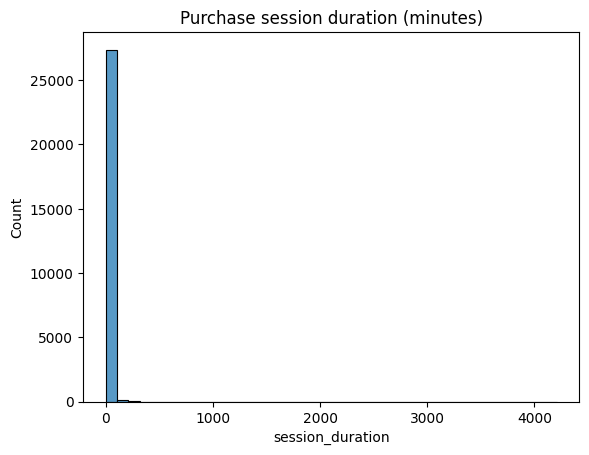

In [166]:
sns.histplot(
    df_purchase_sessions["session_duration"].dt.total_seconds()/60,
    bins=40
)

plt.title("Purchase session duration (minutes)")
plt.show()

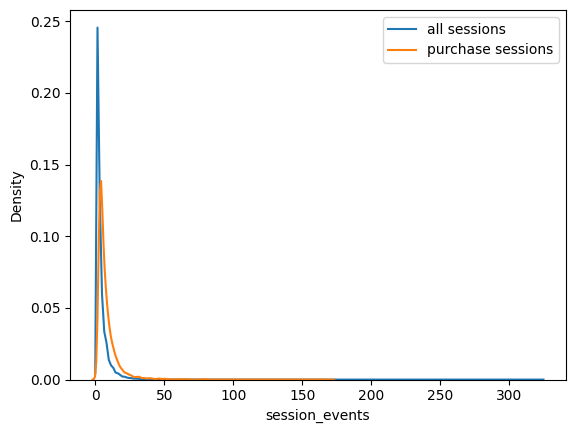

In [167]:
# Sessions normales vs sessions avec achat

sns.kdeplot(session_stats_full["session_events"], label="all sessions")
sns.kdeplot(df_purchase_sessions["session_events"], label="purchase sessions")

plt.legend()

## Session duration exploration (code not used yet, just to show outliers in session durations)

In [53]:
durations_sess = session_stats["session_duration"]

In [54]:
durations_sess.sort_values(ascending=False)

137613   1 days 18:02:42
200736   1 days 16:33:40
181250   1 days 16:06:21
193791   1 days 15:44:23
158761   1 days 14:12:34
               ...      
125618   0 days 00:00:00
125617   0 days 00:00:00
125609   0 days 00:00:00
125608   0 days 00:00:00
245883   0 days 00:00:00
Name: session_duration, Length: 245884, dtype: timedelta64[ns]

In [55]:
durations_sess.describe()

count                       245884
mean     0 days 00:07:39.423024678
std      0 days 01:04:55.265260625
min                0 days 00:00:00
25%                0 days 00:00:00
50%                0 days 00:00:48
75%                0 days 00:03:30
max                1 days 18:02:42
Name: session_duration, dtype: object

In [56]:
crazy_duration = durations_sess[durations_sess > "1 days"]

In [57]:
crazy_duration
# A supprimer des prochaines itérations du modèle après baseline?

303      1 days 00:19:13
451      1 days 13:13:10
485      1 days 00:40:27
802      1 days 02:13:42
1230     1 days 07:33:59
               ...      
211749   1 days 03:00:25
212176   1 days 07:12:15
213517   1 days 03:35:41
216925   1 days 04:08:49
223599   1 days 03:06:03
Name: session_duration, Length: 171, dtype: timedelta64[ns]

## Grouping Session features per user_id for the observation period

In [58]:
# INfos de session par user_ID sur l'intervalle d'observation

session_user = session_stats.groupby("user_id").agg(
    avg_session_duration    = ("session_duration", "mean"),
    median_session_duration = ("session_duration", "median"),
    max_session_duration    = ("session_duration", "max"),
    avg_events_per_session  = ("session_events", "mean"),
    max_events_per_session  = ("session_events", "max"),
)
session_user

,avg_session_duration,median_session_duration,max_session_duration,avg_events_per_session,max_events_per_session
user_id,,,,,
241587569,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
244951053,0 days 00:00:53,0 days 00:00:53,0 days 00:00:53,2.0,2
293335683,0 days 00:05:04.333333333,0 days 00:04:35,0 days 00:09:08,4.0,6
293957954,0 days 00:01:04,0 days 00:01:04,0 days 00:01:04,4.0,4
304497722,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
...,...,...,...,...,...
556194942,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
556194974,0 days 00:00:01,0 days 00:00:01,0 days 00:00:02,1.5,2
556194976,0 days 00:01:10,0 days 00:01:10,0 days 00:01:10,2.0,2


## Features grouping and final X, y

In [59]:
user_features = (behavior.join(session_user, how="left")
)

In [60]:
user_features

,total_events,total_views,total_carts,total_purchases,n_sessions,n_days_active,has_ever_carted,has_ever_purchased,view_to_cart_ratio,cart_to_purchase_ratio,avg_session_duration,median_session_duration,max_session_duration,avg_events_per_session,max_events_per_session
user_id,,,,,,,,,,,,,,,
241587569,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
244951053,2,2,0,0,1,1,0,0,0.0,0.0,0 days 00:00:53,0 days 00:00:53,0 days 00:00:53,2.0,2
293335683,12,12,0,0,3,1,0,0,0.0,0.0,0 days 00:05:04.333333333,0 days 00:04:35,0 days 00:09:08,4.0,6
293957954,4,4,0,0,1,1,0,0,0.0,0.0,0 days 00:01:04,0 days 00:01:04,0 days 00:01:04,4.0,4
304497722,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
556194942,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
556194974,3,3,0,0,2,1,0,0,0.0,0.0,0 days 00:00:01,0 days 00:00:01,0 days 00:00:02,1.5,2
556194976,2,2,0,0,1,1,0,0,0.0,0.0,0 days 00:01:10,0 days 00:01:10,0 days 00:01:10,2.0,2


In [61]:
user_features.isna().sum()

total_events               0
total_views                0
total_carts                0
total_purchases            0
n_sessions                 0
n_days_active              0
has_ever_carted            0
has_ever_purchased         0
view_to_cart_ratio         0
cart_to_purchase_ratio     0
avg_session_duration       0
median_session_duration    0
max_session_duration       0
avg_events_per_session     0
max_events_per_session     0
dtype: int64

In [62]:
dataset = y_purchasers.merge(user_features, on="user_id", how="inner")

In [63]:
dataset

,user_id,label,total_events,total_views,total_carts,total_purchases,n_sessions,n_days_active,has_ever_carted,has_ever_purchased,view_to_cart_ratio,cart_to_purchase_ratio,avg_session_duration,median_session_duration,max_session_duration,avg_events_per_session,max_events_per_session
0,550050854,0,7,7,0,0,1,1,0,0,0.0,0.0,0 days 00:03:16,0 days 00:03:16,0 days 00:03:16,7.0,7
1,535871217,0,10,10,0,0,2,1,0,0,0.0,0.0,0 days 00:01:40,0 days 00:01:40,0 days 00:02:41,5.0,7
2,537918940,0,4,4,0,0,1,1,0,0,0.0,0.0,0 days 00:01:36,0 days 00:01:36,0 days 00:01:36,4.0,4
3,530282093,0,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
4,537192226,0,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169076,546948553,0,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
169077,515429044,0,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
169078,543640816,0,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
169079,516465461,0,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1


In [64]:
X = dataset.drop(columns="label")

In [65]:
X

,user_id,total_events,total_views,total_carts,total_purchases,n_sessions,n_days_active,has_ever_carted,has_ever_purchased,view_to_cart_ratio,cart_to_purchase_ratio,avg_session_duration,median_session_duration,max_session_duration,avg_events_per_session,max_events_per_session
0,550050854,7,7,0,0,1,1,0,0,0.0,0.0,0 days 00:03:16,0 days 00:03:16,0 days 00:03:16,7.0,7
1,535871217,10,10,0,0,2,1,0,0,0.0,0.0,0 days 00:01:40,0 days 00:01:40,0 days 00:02:41,5.0,7
2,537918940,4,4,0,0,1,1,0,0,0.0,0.0,0 days 00:01:36,0 days 00:01:36,0 days 00:01:36,4.0,4
3,530282093,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
4,537192226,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169076,546948553,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
169077,515429044,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
169078,543640816,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
169079,516465461,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1


In [66]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169081 entries, 0 to 169080
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype          
---  ------                   --------------   -----          
 0   user_id                  169081 non-null  int32          
 1   total_events             169081 non-null  int64          
 2   total_views              169081 non-null  int64          
 3   total_carts              169081 non-null  int64          
 4   total_purchases          169081 non-null  int64          
 5   n_sessions               169081 non-null  int64          
 6   n_days_active            169081 non-null  int64          
 7   has_ever_carted          169081 non-null  int8           
 8   has_ever_purchased       169081 non-null  int8           
 9   view_to_cart_ratio       169081 non-null  float64        
 10  cart_to_purchase_ratio   169081 non-null  float64        
 11  avg_session_duration     169081 non-null  timedelta64[ns]
 12  me

In [67]:
for col in ["avg_session_duration", "median_session_duration", "max_session_duration"]:
    X[col] = X[col].dt.total_seconds()


X = X.astype("float32")

In [68]:
X = X.drop(columns="user_id")

In [69]:
X

,total_events,total_views,total_carts,total_purchases,n_sessions,n_days_active,has_ever_carted,has_ever_purchased,view_to_cart_ratio,cart_to_purchase_ratio,avg_session_duration,median_session_duration,max_session_duration,avg_events_per_session,max_events_per_session
0,7.0,7.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,196.0,196.0,196.0,7.0,7.0
1,10.0,10.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,100.0,100.0,161.0,5.0,7.0
2,4.0,4.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,96.0,96.0,96.0,4.0,4.0
3,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169076,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
169077,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
169078,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
169079,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


In [70]:
y = dataset["label"]
y

0         0
1         0
2         0
3         0
4         0
         ..
169076    0
169077    0
169078    0
169079    0
169080    0
Name: label, Length: 169081, dtype: int64

# Model v1 (baseline) and Train test split 

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [72]:
X_test

,total_events,total_views,total_carts,total_purchases,n_sessions,n_days_active,has_ever_carted,has_ever_purchased,view_to_cart_ratio,cart_to_purchase_ratio,avg_session_duration,median_session_duration,max_session_duration,avg_events_per_session,max_events_per_session
62059,3.0,3.0,0.0,0.0,1.0,1.0,0.0,0.0,0.000000,0.0,160.0,160.0,160.0,3.000000,3.0
150273,2.0,2.0,0.0,0.0,1.0,1.0,0.0,0.0,0.000000,0.0,35.0,35.0,35.0,2.000000,2.0
110799,7.0,7.0,0.0,0.0,1.0,1.0,0.0,0.0,0.000000,0.0,342.0,342.0,342.0,7.000000,7.0
1323,29.0,22.0,5.0,2.0,3.0,1.0,1.0,1.0,0.227273,0.4,486.0,502.0,609.0,9.666667,12.0
61946,2.0,2.0,0.0,0.0,1.0,1.0,0.0,0.0,0.000000,0.0,32.0,32.0,32.0,2.000000,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55459,2.0,2.0,0.0,0.0,1.0,1.0,0.0,0.0,0.000000,0.0,72.0,72.0,72.0,2.000000,2.0
25679,3.0,3.0,0.0,0.0,1.0,1.0,0.0,0.0,0.000000,0.0,128.0,128.0,128.0,3.000000,3.0
135425,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,1.000000,1.0
106771,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,1.000000,1.0


In [73]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
base_spw = neg / pos
base_spw
# Combien de fois les non acheteurs sont présents de plus que les acheteurs

np.float64(31.672463768115943)

In [74]:
model_lgbm = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=500,
    scale_pos_weight=base_spw,
    random_state=42,
    verbosity=-1,
    n_jobs=-1,
)

In [75]:
model_lgbm.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,500
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [76]:
y_test_proba = model_lgbm.predict_proba(X_test)[:, 1]

y_test_pred  = (y_test_proba >= 0.5).astype(int)
#Permet d'ajuster le seuil de probabilité de classification

roc_auc = roc_auc_score(y_test, y_test_proba)
pr_auc  = average_precision_score(y_test, y_test_proba)

In [77]:
roc_auc


0.6888917772419587

In [78]:
pr_auc

0.15950468345249333

In [79]:
recall = recall_score(y_test, y_test_pred)
recall

0.4502415458937198

# Model v1 - Added Standardisation (lower performances! Not reused for model V2)

In [80]:
pipeline = make_pipeline(
    StandardScaler(),
    model_lgbm
)

pipeline.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('lgbmclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1


In [81]:
y_test_proba = pipeline.predict_proba(X_test)[:, 1]


/Users/adrien/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [82]:
roc_auc = roc_auc_score(y_test, y_test_proba)

In [83]:
roc_auc


0.6870292316067171

In [84]:
pr_auc = average_precision_score(y_test, y_test_proba)

In [85]:
pr_auc


0.1575154700018179

## Model v1 - Learning Curves PR AUC standardized

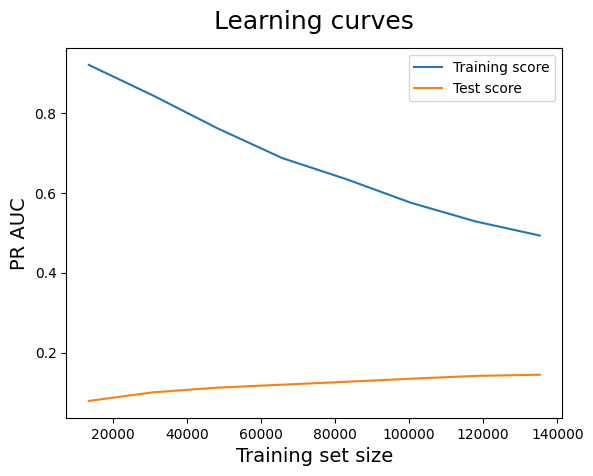

In [86]:
train_sizes, train_scores, val_scores = learning_curve(
    model_lgbm,
    X,
    y,
    cv=5,
    scoring="average_precision",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)


# Take the mean of cross-validated train scores and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(val_scores, axis=1)

plt.plot(train_sizes, train_scores_mean, label = 'Training score')
plt.plot(train_sizes, test_scores_mean, label = 'Test score')
plt.ylabel('PR AUC', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves', fontsize = 18, y = 1.03)
plt.legend()

# Model_v2 - Grid Search for best hyperparameters

In [87]:
from sklearn.model_selection import RandomizedSearchCV


In [88]:
param_dist = {
    "n_estimators": np.arange(100, 600, 100),
    "learning_rate": np.linspace(0.01, 0.2, 20),
    "num_leaves": np.arange(20, 150, 10),
    "max_depth": [-1, 5, 10, 15]
}

search = RandomizedSearchCV(
    model_lgbm,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="average_precision",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
print(search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'num_leaves': np.int64(40), 'n_estimators': np.int64(200), 'max_depth': 5, 'learning_rate': np.float64(0.04)}


# Model V2 with GridSearch best hyperparams (Best model to date)

In [89]:
model_lgbm_v2 = lgb.LGBMClassifier(
    objective="binary",
    scale_pos_weight=base_spw,
    random_state=42,
    verbosity=-1,
    n_jobs=-1,
    num_leaves=40,
    n_estimators=200,
    max_depth=5,
    learning_rate=0.04
)

In [90]:
model_lgbm_v2.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,40
,max_depth,5
,learning_rate,0.04
,n_estimators,200
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [91]:
y_test_proba_2 = model_lgbm_v2.predict_proba(X_test)[:, 1]
y_test_pred_2  = (y_test_proba_2 >= 0.5).astype(int)

In [92]:
roc_auc_2 = roc_auc_score(y_test, y_test_proba_2)
pr_auc_2  = average_precision_score(y_test, y_test_proba_2)

In [93]:
roc_auc_2

0.7705538593849518

In [94]:
pr_auc_2

0.20059446154670119

In [95]:
recall_2 = recall_score(y_test, y_test_pred_2)
recall_2

0.6193236714975845

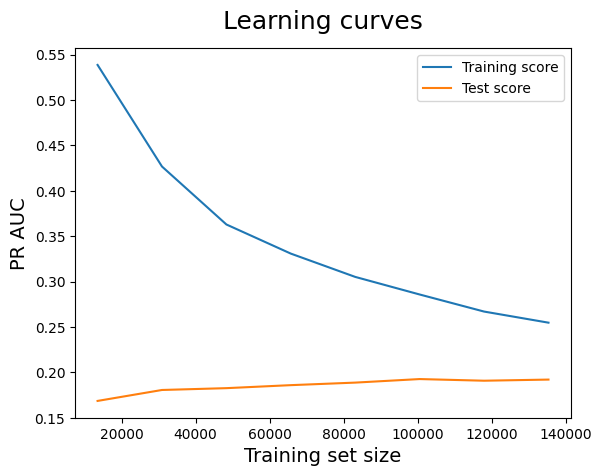

In [96]:
train_sizes, train_scores, val_scores = learning_curve(
    model_lgbm_v2,
    X,
    y,
    cv=5,
    scoring="average_precision",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)


# Take the mean of cross-validated train scores and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(val_scores, axis=1)

plt.plot(train_sizes, train_scores_mean, label = 'Training score')
plt.plot(train_sizes, test_scores_mean, label = 'Test score')
plt.ylabel('PR AUC', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves', fontsize = 18, y = 1.03)
plt.legend()

In [97]:
y_pred = model_lgbm_v2.predict(X_test)

print("\nClassification report:")
print(classification_report(y_test, y_pred))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))



Classification report:
              precision    recall  f1-score   support

           0       0.99      0.82      0.89     32782
           1       0.10      0.62      0.17      1035

    accuracy                           0.81     33817
   macro avg       0.54      0.72      0.53     33817
weighted avg       0.96      0.81      0.87     33817


Confusion matrix:
[[26807  5975]
 [  394   641]]
